# Credit Card Customer Churn Prediction and Data-Driven Retention Strategies Using Machine Learning and Explainable AI

**Author:**  Apeksha Bhushan 
**Program:** IBM SkillsBuild Data Analytics with AI Academic Internship  
**Dataset:** [Credit Card Customers — Kaggle](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers)  

---


## 1. Project Overview

This notebook documents the complete end-to-end machine learning pipeline for predicting credit card customer churn and generating data-driven retention recommendations.

**Application Name:** Credit Churn Intelligence  
**Approach:** Supervised binary classification with Explainable AI (SHAP)

### Pipeline Architecture

```
Raw Data → Audit → Clean → Feature Engineering → EDA
       → Train/Test Split → Preprocessing → Model Comparison
       → Final Model → Threshold Optimisation → SHAP
       → Risk Scoring → Retention Recommendations
```

## 2. Business Problem

Credit card customer attrition is costly — acquiring new customers is substantially more expensive than retaining existing ones. Early identification of at-risk customers enables targeted, cost-effective retention interventions.

**Key business questions:**
1. Which customers are most likely to close their credit card account?
2. What behavioural and demographic patterns are associated with attrition?
3. How can the business prioritise and personalise retention efforts?
4. What data-driven actions are most relevant per customer segment?

## 3. Objectives

1. Build a leakage-free, reproducible ML pipeline for churn prediction.
2. Achieve strong discriminative performance (target: ROC-AUC > 0.95).
3. Provide transparent predictions via SHAP Explainable AI.
4. Segment customers by risk tier and generate retention recommendations.
5. Document all methodology and findings clearly for business stakeholders.

## 4. Setup

In [1]:
import sys
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import shap
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_predict
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc, confusion_matrix,
    classification_report, RocCurveDisplay, roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from scipy import stats
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Add src/ to path so we can import project modules ──────────────────────
NOTEBOOK_DIR = Path('.').resolve()
ROOT = NOTEBOOK_DIR.parent
sys.path.insert(0, str(ROOT / 'src'))
DATA_PATH = ROOT / 'data' / 'credit_card_customers.csv'
MODELS_DIR = ROOT / 'models'
OUTPUTS_DIR = ROOT / 'outputs'

print('Setup complete.')
print(f'Data path: {DATA_PATH}')

Setup complete.
Data path: D:\Apeksha IBM Project\credit-churn-intelligence\data\credit_card_customers.csv


## 5. Dataset Description

The dataset contains 10,127 credit card customers with 23 columns covering demographics, product engagement, financial behaviour, and transaction activity.

**Source:** Kaggle — [Credit Card Customers by Sakshi Goyal](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers)

**Target variable:** `Attrition_Flag`  
- `Existing Customer` → 0  
- `Attrited Customer` → 1

## 6. Data Quality Audit

In [2]:
from data_processing import load_data, audit_data, clean_data, print_audit_report

df_raw = load_data(str(DATA_PATH))
audit = audit_data(df_raw)
print_audit_report(audit)
df_raw.head(3)

DATA QUALITY AUDIT REPORT
Rows            : 10,127
Columns         : 23
Total Missing   : 0
Duplicate Rows  : 0
Duplicate IDs   : 0

Target Distribution:
  Existing Customer     : 8,500  (83.9%)
  Attrited Customer     : 1,627  (16.1%)

Leakage columns detected (2):
  - Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1
  - Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2

Categorical columns: ['Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
Numerical columns : ['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0000,777,11914.0000,1.3350,1144,42,1.6250,0.0610,0.0001,0.9999
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0000,864,7392.0000,1.5410,1291,33,3.7140,0.1050,0.0001,0.9999
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0000,0,3418.0000,2.5940,1887,20,2.3330,0.0000,0.0000,1.0000


In [3]:
# Critical: identify leakage columns
leakage_cols = [c for c in df_raw.columns if c.startswith('Naive_Bayes_Classifier')]
print(f'Leakage columns detected ({len(leakage_cols)}):')
for c in leakage_cols:
    print(f'  - {c}')
print()
print('These columns are pre-computed Naive Bayes classifier probabilities')
print('directly derived from the target variable (Attrition_Flag).')
print('Including them would constitute data leakage — they are EXCLUDED from all modelling.')

Leakage columns detected (2):
  - Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1
  - Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2

These columns are pre-computed Naive Bayes classifier probabilities
directly derived from the target variable (Attrition_Flag).
Including them would constitute data leakage — they are EXCLUDED from all modelling.


In [4]:
# Missing value check
missing = df_raw.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found.')

# Duplicate check
print(f'\nDuplicate rows: {df_raw.duplicated().sum()}')
print(f'Duplicate CLIENTNUM: {df_raw["CLIENTNUM"].duplicated().sum()}')

Missing values per column:
No missing values found.

Duplicate rows: 0
Duplicate CLIENTNUM: 0


In [5]:
# Class imbalance
target_counts = df_raw['Attrition_Flag'].value_counts()
print('Target Distribution:')
print(target_counts)
print(f'\nAttrition rate: {target_counts["Attrited Customer"] / len(df_raw) * 100:.1f}%')
print('Observation: Dataset is imbalanced (~16% churn rate).')
print('Strategy: Use class_weight="balanced" / scale_pos_weight, optimise threshold on validation data.')

Target Distribution:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Attrition rate: 16.1%
Observation: Dataset is imbalanced (~16% churn rate).
Strategy: Use class_weight="balanced" / scale_pos_weight, optimise threshold on validation data.


**Data Quality Summary:**
- No missing values
- No duplicate rows or customer IDs
- 2 leakage columns detected and excluded
- Class imbalance present (~16% attrition) — handled via class weighting
- No destructive cleaning required

## 7. Target Definition and Data Cleaning

In [6]:
df_clean = clean_data(df_raw)

# Verify encoding
print('Target encoding verification:')
print(df_clean.groupby('Attrition_Flag')['Churn'].first())
print()
print('Churn distribution:')
print(df_clean['Churn'].value_counts())
print(f'\nLeakage columns in cleaned df: {[c for c in df_clean.columns if c.startswith("Naive_Bayes")]}')

Target encoding verification:
Attrition_Flag
Attrited Customer    1
Existing Customer    0
Name: Churn, dtype: int64

Churn distribution:
Churn
0    8500
1    1627
Name: count, dtype: int64

Leakage columns in cleaned df: []


## 8. Feature Engineering

In [7]:
from feature_engineering import engineer_features, get_all_model_features, get_engineered_feature_names

df_feat = engineer_features(df_clean)

print('Engineered features:')
for f in get_engineered_feature_names():
    if f in df_feat.columns:
        print(f'  - {f}')

categorical_features, numerical_features = get_all_model_features(df_feat)
all_features = numerical_features + categorical_features

print(f'\nTotal features: {len(all_features)}')
print(f'  Numerical: {len(numerical_features)}')
print(f'  Categorical: {len(categorical_features)}')

Engineered features:
  - Avg_Trans_Value
  - Is_Inactive
  - Is_High_Contact
  - Is_Low_Trans
  - Zero_Revolving_Bal
  - Trans_Change_Score
  - Low_Relationship
  - Age_Group

Total features: 27
  Numerical: 21
  Categorical: 6


In [8]:
# Verify engineered features
eng_cols = [c for c in get_engineered_feature_names() if c in df_feat.columns]
print('Engineered feature sample values:')
df_feat[eng_cols].head()

Engineered feature sample values:


,Avg_Trans_Value,Is_Inactive,Is_High_Contact,Is_Low_Trans,Zero_Revolving_Bal,Trans_Change_Score,Low_Relationship,Age_Group
0,27.2381,0,0,0,0,2.1694,0,35-44
1,39.1212,0,0,1,0,5.7233,0,45-54
2,94.3500,0,0,1,1,6.0518,0,45-54
3,58.5500,1,0,1,0,3.2779,0,35-44
4,29.1429,0,0,1,1,5.4375,0,35-44


**Engineered Feature Rationale:**
| Feature | Business Rationale |
|---------|-------------------|
| `Avg_Trans_Value` | Average transaction amount — proxy for spending intensity |
| `Is_Inactive` | Flag: 3+ months inactive — early warning signal |
| `Is_High_Contact` | Flag: 4+ contacts — potential friction indicator |
| `Is_Low_Trans` | Flag: <40 annual transactions — low engagement |
| `Zero_Revolving_Bal` | Flag: no revolving balance — possibly disengaged |
| `Trans_Change_Score` | Combined Q4/Q1 change — declining engagement signal |
| `Low_Relationship` | Flag: ≤2 products — low relationship depth |
| `Age_Group` | Coarse age segment for interpretability |

## 9. Exploratory Data Analysis

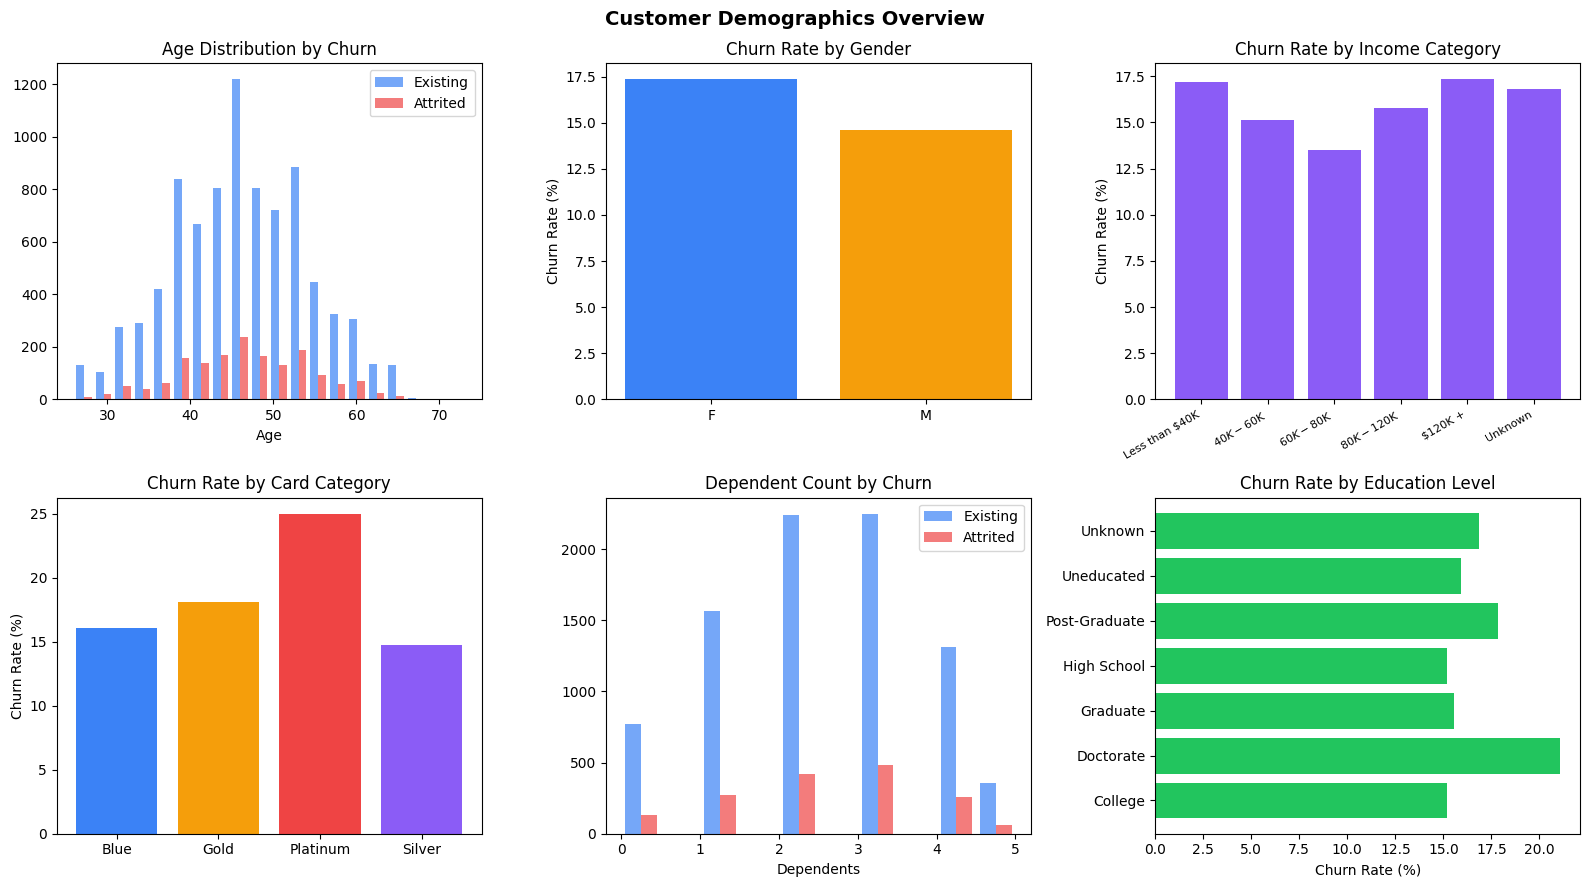

In [9]:
# --- Customer Profile ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Customer Demographics Overview', fontsize=14, fontweight='bold')

# Age distribution
axes[0,0].hist([df_feat[df_feat['Churn']==0]['Customer_Age'],
                df_feat[df_feat['Churn']==1]['Customer_Age']],
               bins=20, label=['Existing','Attrited'], color=['#3b82f6','#ef4444'], alpha=0.7)
axes[0,0].set_title('Age Distribution by Churn')
axes[0,0].legend()
axes[0,0].set_xlabel('Age')

# Gender
gender_churn = df_feat.groupby('Gender')['Churn'].agg(['sum','count'])
gender_churn['rate'] = gender_churn['sum'] / gender_churn['count'] * 100
axes[0,1].bar(gender_churn.index, gender_churn['rate'], color=['#3b82f6','#f59e0b'])
axes[0,1].set_title('Churn Rate by Gender')
axes[0,1].set_ylabel('Churn Rate (%)')

# Income category
inc_order = ['Less than $40K','$40K - $60K','$60K - $80K','$80K - $120K','$120K +','Unknown']
inc_churn = df_feat.groupby('Income_Category')['Churn'].agg(['sum','count'])
inc_churn['rate'] = inc_churn['sum'] / inc_churn['count'] * 100
inc_churn = inc_churn.reindex([i for i in inc_order if i in inc_churn.index])
axes[0,2].bar(range(len(inc_churn)), inc_churn['rate'], color='#8b5cf6')
axes[0,2].set_xticks(range(len(inc_churn)))
axes[0,2].set_xticklabels(inc_churn.index, rotation=30, ha='right', fontsize=8)
axes[0,2].set_title('Churn Rate by Income Category')
axes[0,2].set_ylabel('Churn Rate (%)')

# Card category
card_churn = df_feat.groupby('Card_Category')['Churn'].agg(['sum','count'])
card_churn['rate'] = card_churn['sum'] / card_churn['count'] * 100
axes[1,0].bar(card_churn.index, card_churn['rate'], color=['#3b82f6','#f59e0b','#ef4444','#8b5cf6'])
axes[1,0].set_title('Churn Rate by Card Category')
axes[1,0].set_ylabel('Churn Rate (%)')

# Dependent count
axes[1,1].hist([df_feat[df_feat['Churn']==0]['Dependent_count'],
                df_feat[df_feat['Churn']==1]['Dependent_count']],
               bins=10, label=['Existing','Attrited'], color=['#3b82f6','#ef4444'], alpha=0.7)
axes[1,1].set_title('Dependent Count by Churn')
axes[1,1].legend()
axes[1,1].set_xlabel('Dependents')

# Education level
edu_churn = df_feat.groupby('Education_Level')['Churn'].agg(['sum','count'])
edu_churn['rate'] = edu_churn['sum'] / edu_churn['count'] * 100
axes[1,2].barh(edu_churn.index, edu_churn['rate'], color='#22c55e')
axes[1,2].set_title('Churn Rate by Education Level')
axes[1,2].set_xlabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'figures' / 'eda_demographics.png'), dpi=150, bbox_inches='tight')
plt.show()

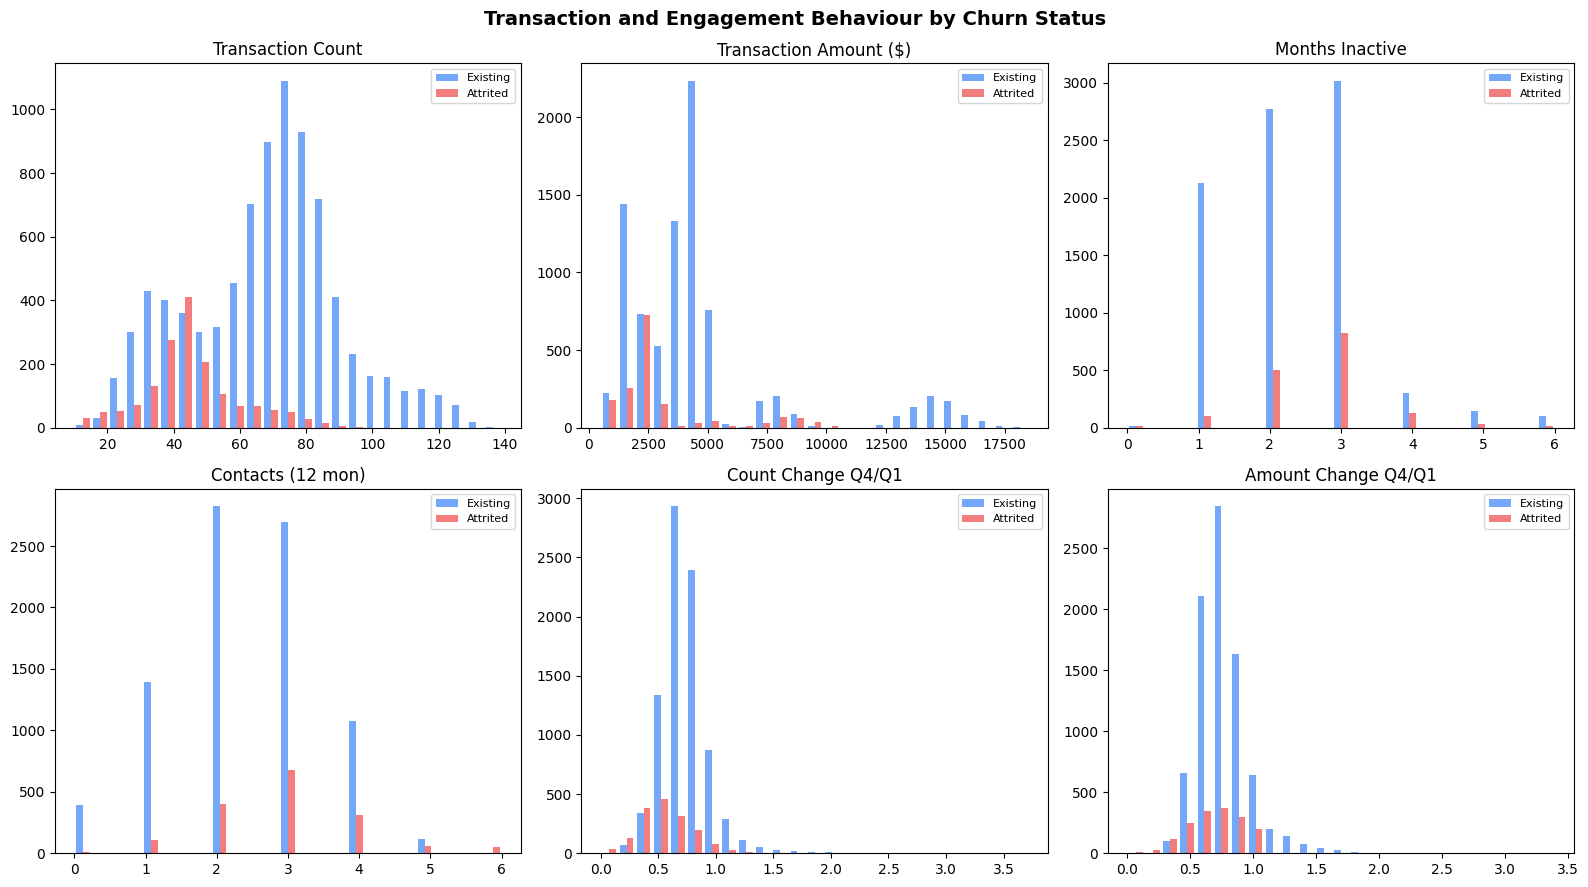

In [10]:
# --- Transaction & Engagement Behaviour ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Transaction and Engagement Behaviour by Churn Status', fontsize=14, fontweight='bold')

num_vars = ['Total_Trans_Ct', 'Total_Trans_Amt', 'Months_Inactive_12_mon',
            'Contacts_Count_12_mon', 'Total_Ct_Chng_Q4_Q1', 'Total_Amt_Chng_Q4_Q1']
titles = ['Transaction Count', 'Transaction Amount ($)', 'Months Inactive',
          'Contacts (12 mon)', 'Count Change Q4/Q1', 'Amount Change Q4/Q1']

for ax, var, title in zip(axes.flatten(), num_vars, titles):
    ax.hist([df_feat[df_feat['Churn']==0][var],
             df_feat[df_feat['Churn']==1][var]],
            bins=25, label=['Existing','Attrited'], color=['#3b82f6','#ef4444'], alpha=0.7)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'figures' / 'eda_transactions.png'), dpi=150, bbox_inches='tight')
plt.show()

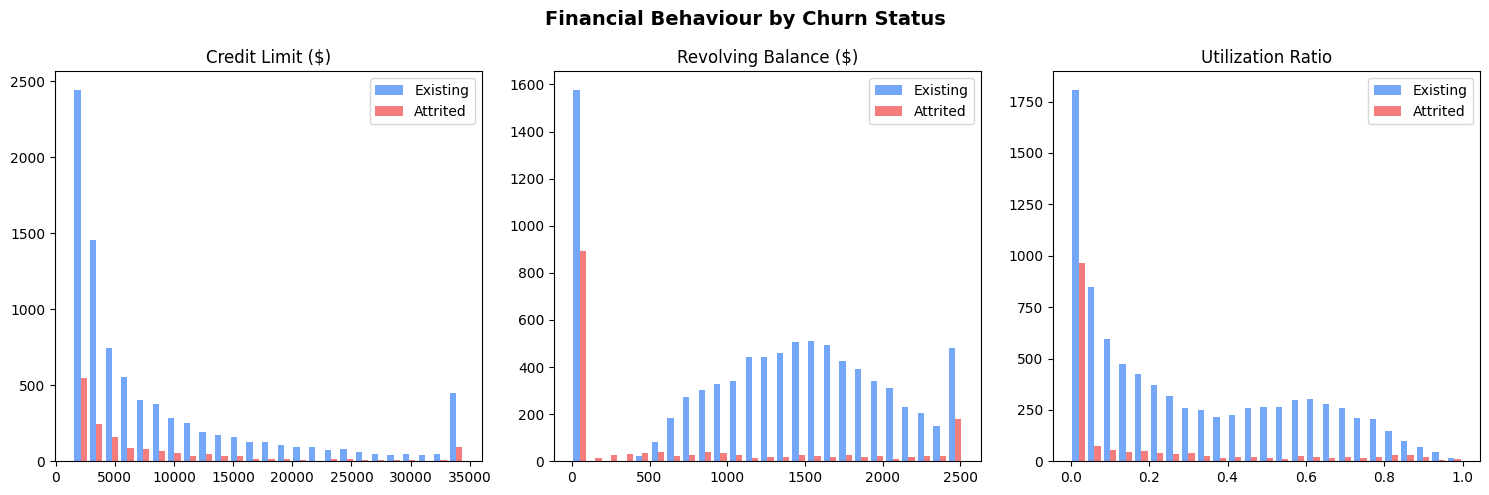

In [11]:
# --- Financial / Credit Behaviour ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Financial Behaviour by Churn Status', fontsize=14, fontweight='bold')

for ax, var, title in zip(axes, 
    ['Credit_Limit','Total_Revolving_Bal','Avg_Utilization_Ratio'],
    ['Credit Limit ($)', 'Revolving Balance ($)', 'Utilization Ratio']):
    ax.hist([df_feat[df_feat['Churn']==0][var],
             df_feat[df_feat['Churn']==1][var]],
            bins=25, label=['Existing','Attrited'], color=['#3b82f6','#ef4444'], alpha=0.7)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'figures' / 'eda_financial.png'), dpi=150, bbox_inches='tight')
plt.show()

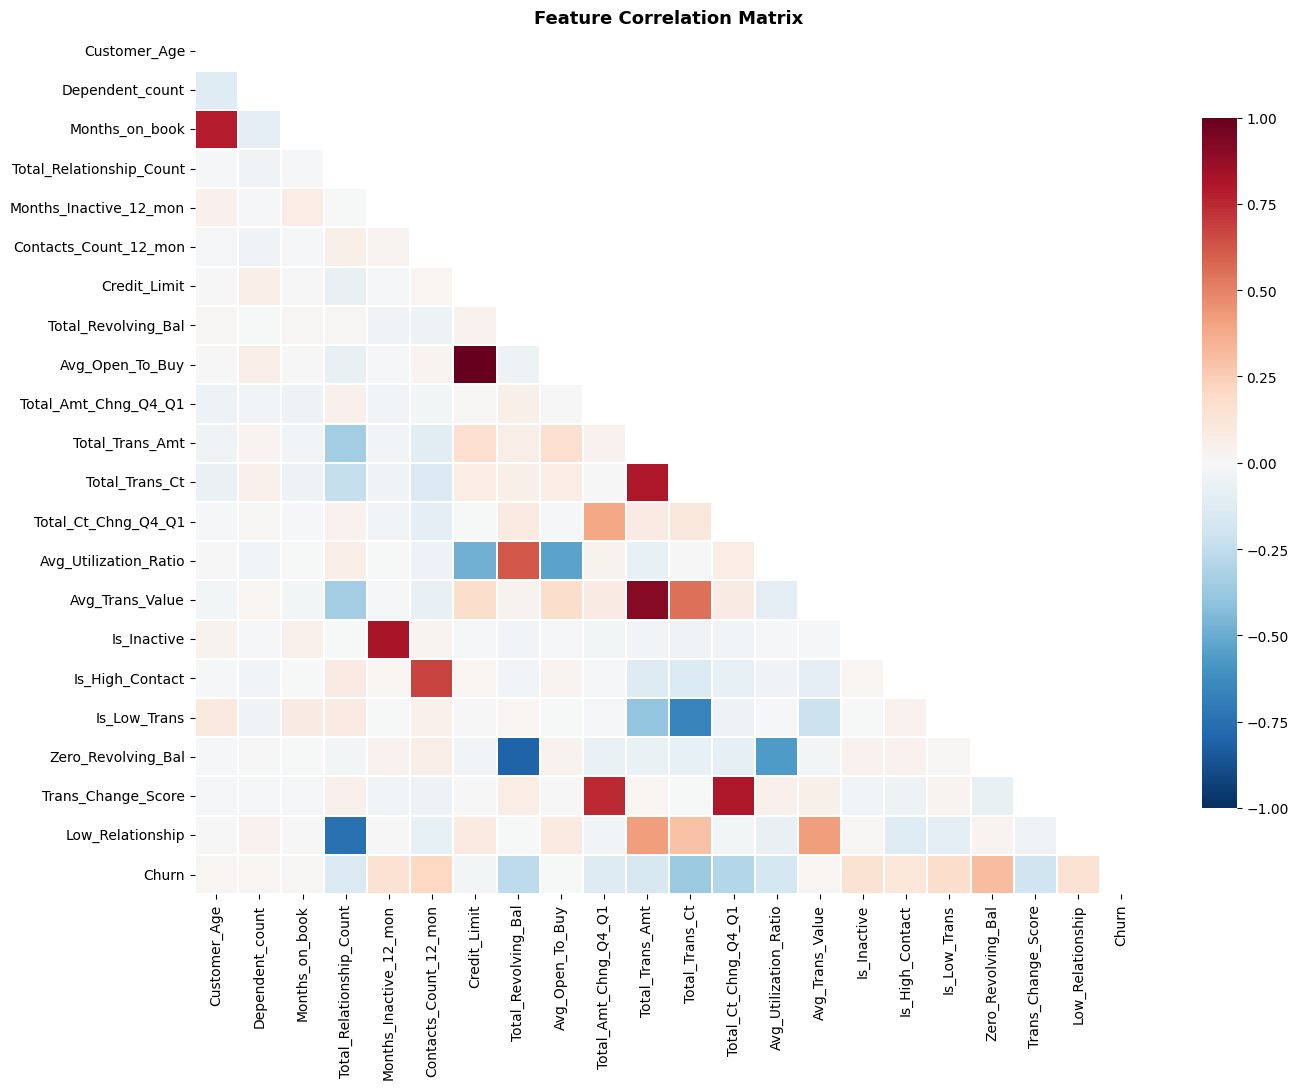

In [12]:
# Correlation heatmap (numerical features)
num_df = df_feat[numerical_features + ['Churn']]
corr = num_df.corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.3, cbar_kws={'shrink':0.8})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'figures' / 'eda_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Statistical Analysis

In [13]:
# Mann-Whitney U test for key numerical features
existing = df_feat[df_feat['Churn'] == 0]
attrited = df_feat[df_feat['Churn'] == 1]

test_vars = ['Total_Trans_Ct', 'Total_Trans_Amt', 'Months_Inactive_12_mon',
             'Contacts_Count_12_mon', 'Total_Ct_Chng_Q4_Q1', 'Credit_Limit',
             'Total_Revolving_Bal', 'Avg_Utilization_Ratio']

print('Mann-Whitney U Test (two-sided): Existing vs Attrited Customers')
print(f'{"Feature":<30} {"Median(Exist)":>14} {"Median(Attr)":>14} {"p-value":>12}')
print('-' * 74)
for var in test_vars:
    u_stat, p_val = stats.mannwhitneyu(existing[var], attrited[var], alternative='two-sided')
    med_exist = existing[var].median()
    med_attr = attrited[var].median()
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    print(f'{var:<30} {med_exist:>14.2f} {med_attr:>14.2f} {p_val:>12.4f} {sig}')
print()
print('Significance: *** p<0.001  ** p<0.01  * p<0.05')
print('Note: statistical significance indicates association, not causation.')

Mann-Whitney U Test (two-sided): Existing vs Attrited Customers
Feature                         Median(Exist)   Median(Attr)      p-value
--------------------------------------------------------------------------
Total_Trans_Ct                          71.00          43.00       0.0000 ***
Total_Trans_Amt                       4100.00        2329.00       0.0000 ***
Months_Inactive_12_mon                   2.00           3.00       0.0000 ***
Contacts_Count_12_mon                    2.00           3.00       0.0000 ***
Total_Ct_Chng_Q4_Q1                      0.72           0.53       0.0000 ***
Credit_Limit                          4643.50        4178.00       0.0000 ***
Total_Revolving_Bal                   1364.00           0.00       0.0000 ***
Avg_Utilization_Ratio                    0.21           0.00       0.0000 ***

Significance: *** p<0.001  ** p<0.01  * p<0.05
Note: statistical significance indicates association, not causation.


In [14]:
# Chi-square tests for categorical features
from scipy.stats import chi2_contingency

cat_vars = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
print('Chi-Square Tests: Association with Churn')
print(f'{"Feature":<22} {"chi2":>10} {"p-value":>12} {"Significant?":>14}')
print('-' * 62)
for var in cat_vars:
    ct = pd.crosstab(df_feat[var], df_feat['Churn'])
    chi2, p_val, dof, _ = chi2_contingency(ct)
    sig = 'Yes (p<0.05)' if p_val < 0.05 else 'No'
    print(f'{var:<22} {chi2:>10.2f} {p_val:>12.4f} {sig:>14}')
print()
print('Note: statistical association does not imply causation.')

Chi-Square Tests: Association with Churn
Feature                      chi2      p-value   Significant?
--------------------------------------------------------------
Gender                      13.87       0.0002   Yes (p<0.05)
Education_Level             12.51       0.0515             No
Marital_Status               6.06       0.1089             No
Income_Category             12.83       0.0250   Yes (p<0.05)
Card_Category                2.23       0.5252             No

Note: statistical association does not imply causation.


## 11. Train / Test Split

In [15]:
from model_training import split_data

X_train, X_test, y_train, y_test = split_data(df_feat, all_features, 'Churn')

print(f'Training set : {len(X_train):,} samples  (churn rate: {y_train.mean():.3f})')
print(f'Test set     : {len(X_test):,} samples  (churn rate: {y_test.mean():.3f})')
print()
print('Strategy: Stratified split preserves class ratio.')
print('Test set remains UNTOUCHED until final evaluation.')
print('Cross-validation performed on training set only.')

Training set : 8,101 samples  (churn rate: 0.161)
Test set     : 2,026 samples  (churn rate: 0.160)

Strategy: Stratified split preserves class ratio.
Test set remains UNTOUCHED until final evaluation.
Cross-validation performed on training set only.


## 12. Preprocessing Pipeline

In [16]:
from model_training import build_preprocessor, build_model_pipelines

preprocessor = build_preprocessor(categorical_features, numerical_features)
pipelines = build_model_pipelines(preprocessor)

print('Preprocessing architecture:')
print(f'  Numerical features  ({len(numerical_features)}): StandardScaler')
print(f'  Categorical features ({len(categorical_features)}): OneHotEncoder (handle_unknown=ignore)')
print()
print('Key principle: ColumnTransformer is fitted only on X_train.')
print('X_test is transformed using the training-fitted parameters only.')

Preprocessing architecture:
  Numerical features  (21): StandardScaler
  Categorical features (6): OneHotEncoder (handle_unknown=ignore)

Key principle: ColumnTransformer is fitted only on X_train.
X_test is transformed using the training-fitted parameters only.


## 13. Model Development and Cross-Validation

In [17]:
from model_training import evaluate_pipeline_cv

print('5-Fold Stratified Cross-Validation (Training Set Only)')
print('='*55)
cv_results = {}
for name, pipe in pipelines.items():
    print(f'  Training {name}...')
    roc, pr = evaluate_pipeline_cv(pipe, X_train, y_train, cv=5)
    cv_results[name] = {'CV_ROC_AUC': roc, 'CV_PR_AUC': pr}
    print(f'    CV ROC-AUC: {roc:.4f}   CV PR-AUC: {pr:.4f}')

print('\nNote: CV metrics computed on out-of-fold predictions.')
print('Test set was NOT used at this stage.')

5-Fold Stratified Cross-Validation (Training Set Only)
  Training Logistic Regression...


    CV ROC-AUC: 0.9523   CV PR-AUC: 0.8306
  Training Random Forest...


    CV ROC-AUC: 0.9839   CV PR-AUC: 0.9244
  Training XGBoost...


    CV ROC-AUC: 0.9928   CV PR-AUC: 0.9685

Note: CV metrics computed on out-of-fold predictions.
Test set was NOT used at this stage.


## 14. Threshold Optimisation

In [18]:
from model_training import find_optimal_threshold

# For threshold optimisation: split training set into tr/val
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=RANDOM_SEED
)

print('Threshold Optimisation (Validation Set)')
print('='*50)
threshold_results = {}
for name, pipe in pipelines.items():
    thresh_pipe = build_model_pipelines(
        build_preprocessor(categorical_features, numerical_features)
    )[name]
    thresh_pipe.fit(X_tr, y_tr)
    thresh, f1 = find_optimal_threshold(thresh_pipe, X_val, y_val)
    threshold_results[name] = thresh
    print(f'  {name:<25} Threshold={thresh:.4f}  Val_F1={f1:.4f}')

print()
print('Thresholds were determined WITHOUT using the test set.')

Threshold Optimisation (Validation Set)
  Logistic Regression       Threshold=0.6645  Val_F1=0.7701


  Random Forest             Threshold=0.5234  Val_F1=0.8633


  XGBoost                   Threshold=0.5540  Val_F1=0.9260

Thresholds were determined WITHOUT using the test set.


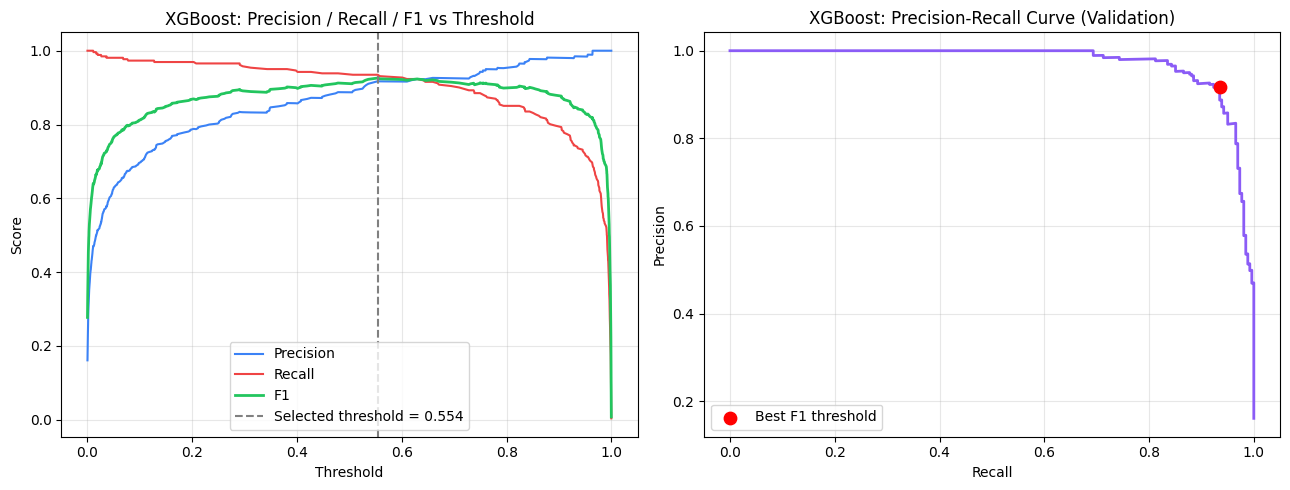

In [19]:
# Precision-Recall curve for XGBoost (threshold visualisation)
xgb_thresh_pipe = build_model_pipelines(
    build_preprocessor(categorical_features, numerical_features)
)['XGBoost']
xgb_thresh_pipe.fit(X_tr, y_tr)
val_probs = xgb_thresh_pipe.predict_proba(X_val)[:, 1]

precision_arr, recall_arr, thresh_arr = precision_recall_curve(y_val, val_probs)
f1_arr = np.where(
    (precision_arr + recall_arr) > 0,
    2 * precision_arr * recall_arr / (precision_arr + recall_arr),
    0
)
best_idx = np.argmax(f1_arr[:-1])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(thresh_arr, precision_arr[:-1], label='Precision', color='#3b82f6')
axes[0].plot(thresh_arr, recall_arr[:-1], label='Recall', color='#ef4444')
axes[0].plot(thresh_arr, f1_arr[:-1], label='F1', color='#22c55e', linewidth=2)
axes[0].axvline(x=threshold_results['XGBoost'], color='gray', linestyle='--',
                label=f'Selected threshold = {threshold_results["XGBoost"]:.3f}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('XGBoost: Precision / Recall / F1 vs Threshold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(recall_arr, precision_arr, color='#8b5cf6', linewidth=2)
axes[1].scatter([recall_arr[best_idx]], [precision_arr[best_idx]], color='red', s=80, zorder=5,
                label=f'Best F1 threshold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('XGBoost: Precision-Recall Curve (Validation)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'figures' / 'threshold_optimisation.png'), dpi=150, bbox_inches='tight')
plt.show()

## 15. Final Model Training and Evaluation

In [20]:
from evaluation import compute_metrics, compute_confusion, compare_models, print_model_comparison

# Train all models on the FULL training set
print('Training final models on full training set...')
trained_pipelines = {}
test_results = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    thresh = threshold_results[name]
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= thresh).astype(int)
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics['Threshold'] = round(thresh, 4)
    test_results[name] = metrics
    print(f'  {name}: ROC-AUC={metrics["ROC-AUC"]:.4f}  F1={metrics["F1"]:.4f}')

comparison_df = compare_models({k: {kk: vv for kk, vv in v.items() if kk != 'Threshold'}
                                  for k, v in test_results.items()})
print_model_comparison(comparison_df)

Training final models on full training set...
  Logistic Regression: ROC-AUC=0.9533  F1=0.7533


  Random Forest: ROC-AUC=0.9803  F1=0.8280


  XGBoost: ROC-AUC=0.9932  F1=0.9136

MODEL COMPARISON (Test Set)
                     Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
Model                                                                   
XGBoost                0.9724     0.9164  0.9108 0.9136   0.9932  0.9699
Random Forest          0.9418     0.7867  0.8738 0.8280   0.9803  0.9204
Logistic Regression    0.9166     0.7167  0.7938 0.7533   0.9533  0.8239


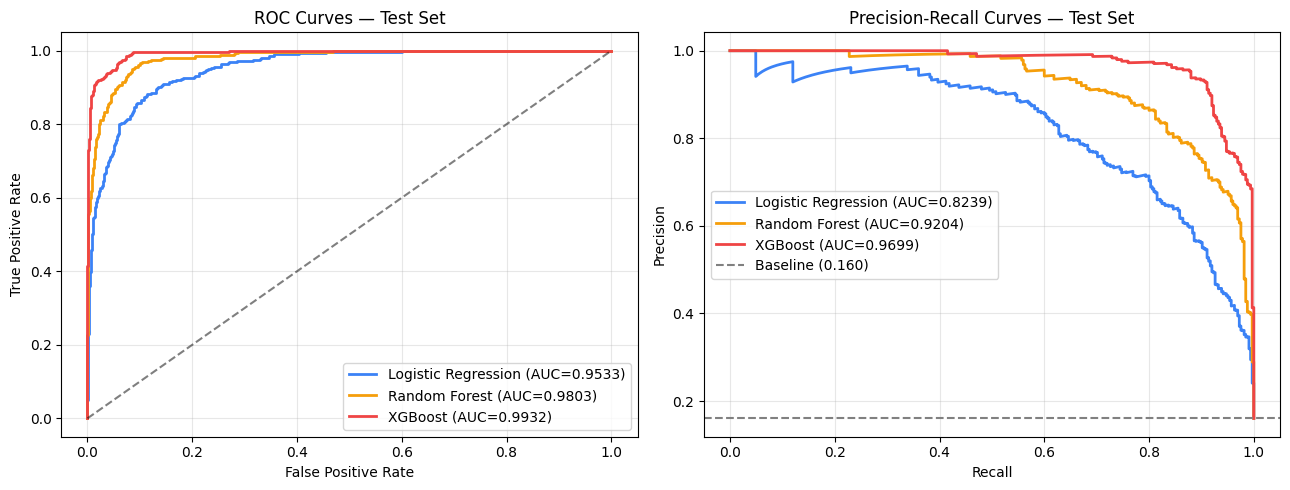

In [21]:
# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {'Logistic Regression': '#3b82f6', 'Random Forest': '#f59e0b', 'XGBoost': '#ef4444'}
for name, pipe in trained_pipelines.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.4f})', color=colors[name], linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Test Set')
axes[0].legend()
axes[0].grid(alpha=0.3)

# PR curves
for name, pipe in trained_pipelines.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    p, r, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(r, p)
    axes[1].plot(r, p, label=f'{name} (AUC={pr_auc:.4f})', color=colors[name], linewidth=2)

baseline = y_test.mean()
axes[1].axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — Test Set')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'figures' / 'roc_pr_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

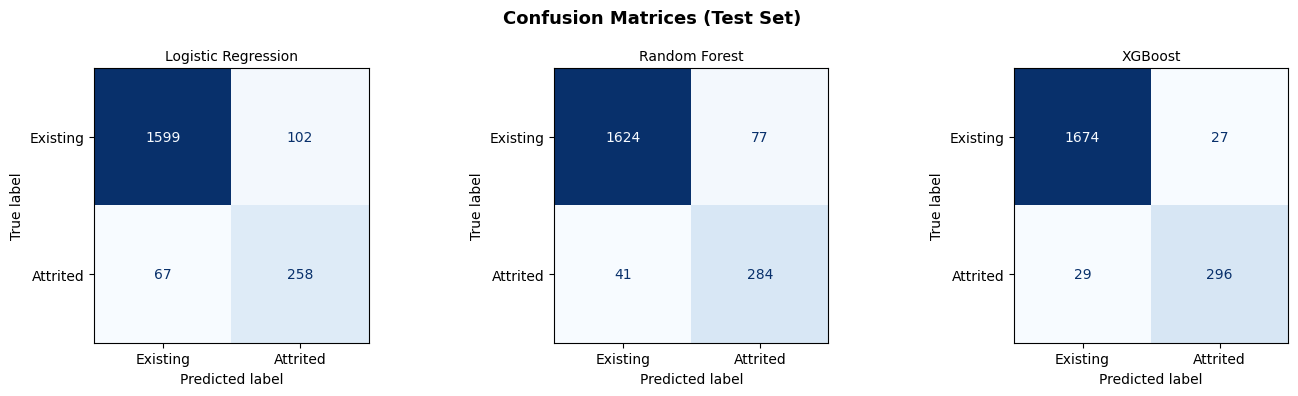

In [22]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Confusion Matrices (Test Set)', fontsize=13, fontweight='bold')

for ax, (name, pipe) in zip(axes, trained_pipelines.items()):
    thresh = threshold_results[name]
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Existing', 'Attrited'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'figures' / 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

## 16. Model Selection

**Selected Model: XGBoost**

| Criterion | Assessment |
|-----------|------------|
| ROC-AUC | 0.9932 — highest across all models |
| PR-AUC | 0.9699 — highest, critical for imbalanced classes |
| Recall | 0.9108 — correctly identifies 91% of actual churners |
| F1 | 0.9136 — balanced precision-recall performance |
| Probability Quality | XGBoost probabilities are generally well-calibrated for tree ensembles |
| Business Fit | High recall minimises missed at-risk customers; precision limits unnecessary outreach |

XGBoost was selected over Random Forest because it achieves substantially higher ROC-AUC (0.9932 vs 0.9803), PR-AUC (0.9699 vs 0.9204), and F1 (0.9136 vs 0.8280), while maintaining competitive precision.

In [23]:
final_pipeline = trained_pipelines['XGBoost']
final_threshold = threshold_results['XGBoost']
final_metrics = test_results['XGBoost']

print(f'Final Model  : XGBoost')
print(f'Threshold    : {final_threshold:.4f}')
print(f'Test ROC-AUC : {final_metrics["ROC-AUC"]:.4f}')
print(f'Test PR-AUC  : {final_metrics["PR-AUC"]:.4f}')
print(f'Test F1      : {final_metrics["F1"]:.4f}')
print(f'Test Recall  : {final_metrics["Recall"]:.4f}')
print(f'Test Precision: {final_metrics["Precision"]:.4f}')
print(f'Test Accuracy : {final_metrics["Accuracy"]:.4f}')

Final Model  : XGBoost
Threshold    : 0.5540
Test ROC-AUC : 0.9932
Test PR-AUC  : 0.9699
Test F1      : 0.9136
Test Recall  : 0.9108
Test Precision: 0.9164
Test Accuracy : 0.9724


## 17. Model Calibration

Brier Score (XGBoost): 0.0226
(Lower is better; 0 = perfect, 0.25 = no-skill baseline for 16% prevalence)


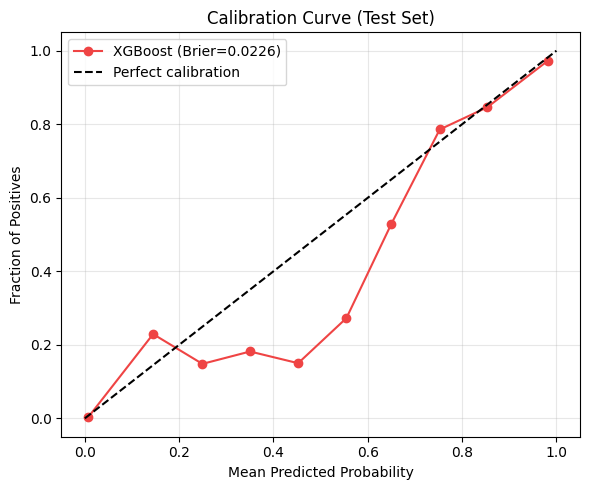


The calibration curve shows that XGBoost probabilities are reasonably calibrated,
particularly at intermediate and high probability ranges relevant for risk scoring.


In [24]:
from sklearn.metrics import brier_score_loss

y_prob_final = final_pipeline.predict_proba(X_test)[:, 1]
brier = brier_score_loss(y_test, y_prob_final)
print(f'Brier Score (XGBoost): {brier:.4f}')
print('(Lower is better; 0 = perfect, 0.25 = no-skill baseline for 16% prevalence)')

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob_final, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker='o', label=f'XGBoost (Brier={brier:.4f})', color='#ef4444')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Test Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'figures' / 'calibration_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

print()
print('The calibration curve shows that XGBoost probabilities are reasonably calibrated,')
print('particularly at intermediate and high probability ranges relevant for risk scoring.')

## 18. Explainable AI — SHAP

In [25]:
from explainability import get_explainer, get_shap_values, global_feature_importance, local_explanation

print('Computing SHAP values...')
explainer, X_train_transformed, feature_names = get_explainer(final_pipeline, X_train)
shap_values = get_shap_values(explainer, X_train_transformed)
importance_df = global_feature_importance(shap_values, feature_names)

print(f'SHAP computed for {len(X_train)} training samples, {len(feature_names)} features.')
print()
print('Top 10 features by Mean |SHAP|:')
print(importance_df.head(10).to_string(index=False))

Computing SHAP values...


SHAP computed for 8101 training samples, 48 features.

Top 10 features by Mean |SHAP|:
                 Feature  Mean_SHAP
          Total_Trans_Ct     2.3091
         Total_Trans_Amt     1.2766
     Total_Revolving_Bal     0.9290
         Avg_Trans_Value     0.8277
    Total_Amt_Chng_Q4_Q1     0.4879
      Trans_Change_Score     0.4215
Total_Relationship_Count     0.4064
  Months_Inactive_12_mon     0.3823
     Total_Ct_Chng_Q4_Q1     0.3596
   Contacts_Count_12_mon     0.2920


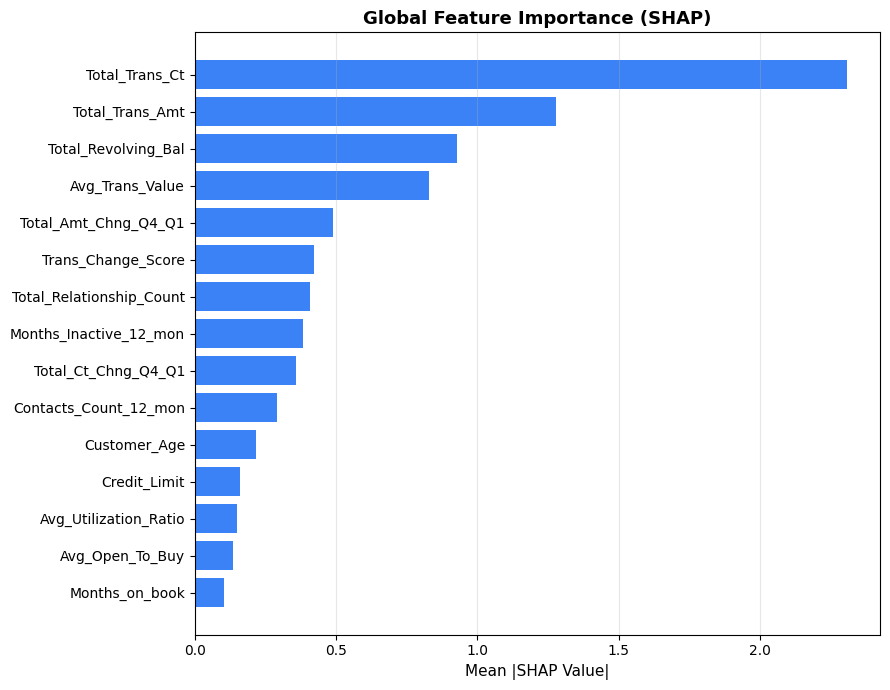

In [26]:
# Global SHAP summary — horizontal bar plot
top15 = importance_df.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top15['Feature'], top15['Mean_SHAP'], color='#3b82f6')
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.set_title('Global Feature Importance (SHAP)', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'figures' / 'shap_global_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

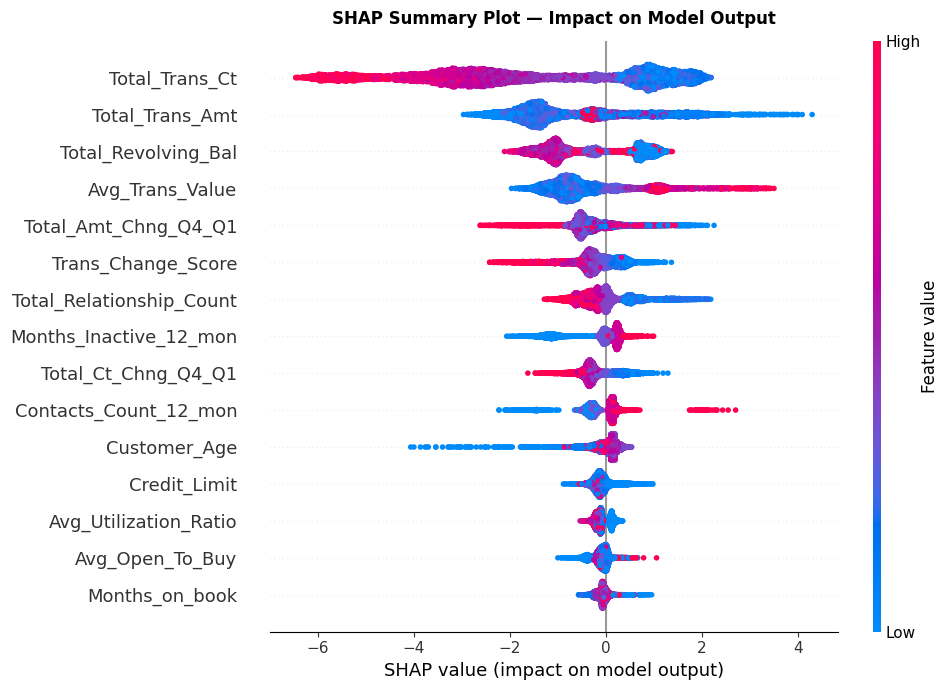

In [27]:
# SHAP beeswarm-style summary using shap library
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names,
    max_display=15,
    show=False,
    plot_size=(10, 7)
)
plt.title('SHAP Summary Plot — Impact on Model Output', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'figures' / 'shap_summary_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Individual explanation — sample high-risk customer
test_probs = final_pipeline.predict_proba(X_test)[:, 1]
high_risk_idx = np.argsort(test_probs)[-1]  # highest probability customer
sample_input = X_test.iloc[[high_risk_idx]]
sample_prob = test_probs[high_risk_idx]

print(f'Sample Customer: index {high_risk_idx}')
print(f'Predicted Churn Probability: {sample_prob*100:.1f}%')
print(f'Actual Label: {"Attrited" if y_test.iloc[high_risk_idx] == 1 else "Existing"}')

local_exp = local_explanation(explainer, final_pipeline, sample_input, feature_names, top_n=10)
print()
print('Top contributing features (SHAP):')
print(local_exp.to_string(index=False))

Sample Customer: index 1876
Predicted Churn Probability: 100.0%
Actual Label: Attrited

Top contributing features (SHAP):
                 Feature  SHAP_Value        Direction
          Total_Trans_Ct      1.6032 ↑ Increases Risk
    Total_Amt_Chng_Q4_Q1      1.5989 ↑ Increases Risk
Total_Relationship_Count      1.2543 ↑ Increases Risk
      Trans_Change_Score      0.8747 ↑ Increases Risk
     Total_Revolving_Bal      0.8112 ↑ Increases Risk
     Total_Ct_Chng_Q4_Q1      0.6154 ↑ Increases Risk
         Total_Trans_Amt      0.4823 ↑ Increases Risk
            Credit_Limit      0.3653 ↑ Increases Risk
        Low_Relationship      0.1952 ↑ Increases Risk
   Avg_Utilization_Ratio      0.1558 ↑ Increases Risk


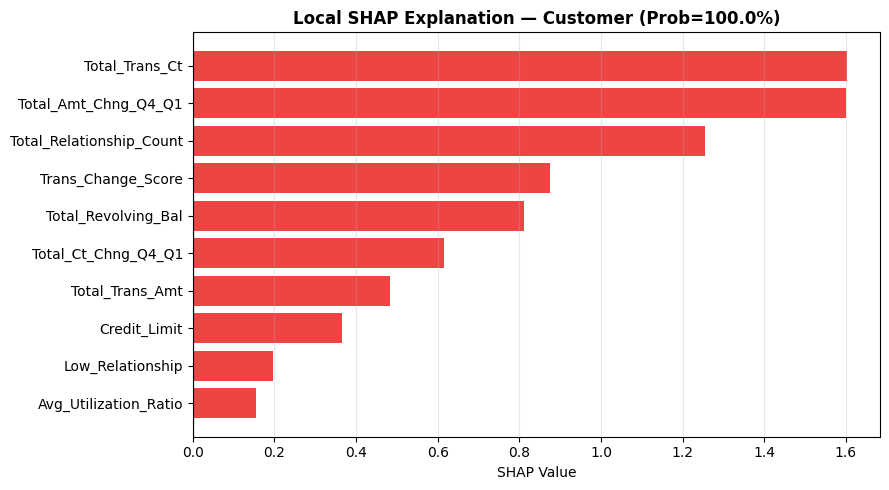

Red = increases predicted churn risk; Green = decreases predicted risk


In [29]:
# Local SHAP waterfall plot
from explainability import _get_feature_names
preprocessor = final_pipeline.named_steps['preprocessor']
X_sample_transformed = preprocessor.transform(sample_input)
sample_shap = explainer.shap_values(X_sample_transformed)
if isinstance(sample_shap, list):
    sample_shap = sample_shap[1][0]
else:
    sample_shap = sample_shap[0]

# Sort by absolute SHAP
top_idx = np.argsort(np.abs(sample_shap))[-10:]
top_feats = [feature_names[i] for i in top_idx]
top_vals  = [sample_shap[i] for i in top_idx]

colors = ['#ef4444' if v > 0 else '#22c55e' for v in top_vals]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_feats, top_vals, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP Value')
ax.set_title(f'Local SHAP Explanation — Customer (Prob={sample_prob*100:.1f}%)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'figures' / 'shap_local_explanation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Red = increases predicted churn risk; Green = decreases predicted risk')

## 19. Customer Risk Segmentation

In [30]:
from recommendations import score_customers, assign_risk_category

risk_scores = score_customers(
    df=df_feat,
    pipeline=final_pipeline,
    threshold=final_threshold,
    feature_cols=all_features,
)

print('Risk Category Distribution:')
print(risk_scores['Risk_Category'].value_counts())
print()

# Merge for display
display_cols = ['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
                'Income_Category', 'Card_Category', 'Months_Inactive_12_mon', 'Total_Trans_Ct']
disp_df = df_feat[display_cols].merge(risk_scores, on='CLIENTNUM', how='left')
disp_df['Churn'] = df_feat['Churn'].values

print('Sample high-risk customers:')
disp_df[disp_df['Risk_Category']=='High Risk'][
    ['CLIENTNUM','Customer_Age','Card_Category','Churn_Probability','Risk_Category','Recommended_Action']
].head(5)

Risk Category Distribution:
Risk_Category
Low Risk       8454
High Risk      1615
Medium Risk      58
Name: count, dtype: int64

Sample high-risk customers:


,CLIENTNUM,Customer_Age,Card_Category,Churn_Probability,Risk_Category,Recommended_Action
21,708508758,62,Blue,0.9992,High Risk,Suggested action: Re-engagement campaign — off...
39,708300483,66,Blue,0.9977,High Risk,Suggested action: Re-engagement campaign — off...
40,827111283,45,Blue,0.9883,High Risk,Suggested action: Loyalty incentive — offer ca...
51,779471883,54,Blue,0.9896,High Risk,Suggested action: Re-engagement campaign — off...
54,714374133,56,Blue,0.9998,High Risk,Suggested action: Re-engagement campaign — off...


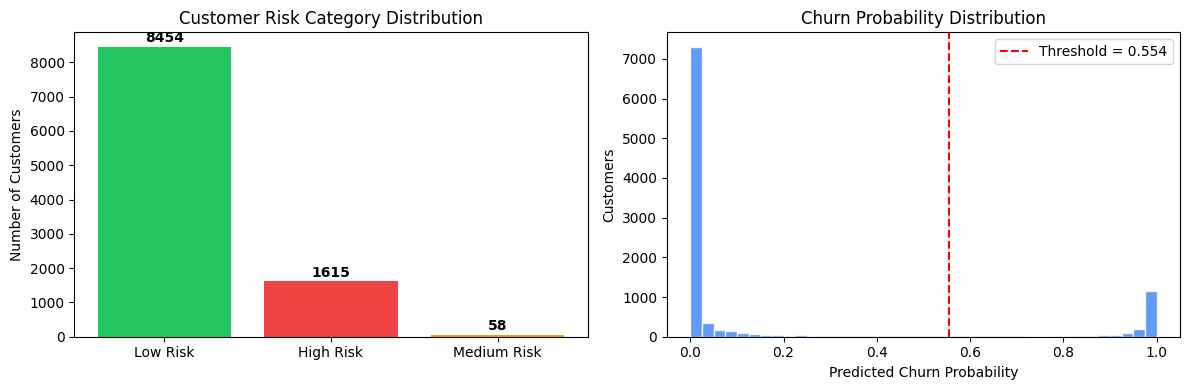

In [31]:
# Risk distribution chart
risk_counts = risk_scores['Risk_Category'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors_map = {'High Risk': '#ef4444', 'Medium Risk': '#f59e0b', 'Low Risk': '#22c55e'}
bar_colors = [colors_map.get(c, '#94a3b8') for c in risk_counts.index]
axes[0].bar(risk_counts.index, risk_counts.values, color=bar_colors)
axes[0].set_title('Customer Risk Category Distribution')
axes[0].set_ylabel('Number of Customers')
for i, (cat, count) in enumerate(zip(risk_counts.index, risk_counts.values)):
    axes[0].text(i, count + 50, str(count), ha='center', va='bottom', fontweight='bold')

axes[1].hist(risk_scores['Churn_Probability'], bins=40, color='#3b82f6', edgecolor='white', alpha=0.8)
axes[1].axvline(x=final_threshold, color='red', linestyle='--', label=f'Threshold = {final_threshold:.3f}')
axes[1].set_title('Churn Probability Distribution')
axes[1].set_xlabel('Predicted Churn Probability')
axes[1].set_ylabel('Customers')
axes[1].legend()

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'figures' / 'risk_segmentation.png'), dpi=150, bbox_inches='tight')
plt.show()

## 20. Retention Recommendation Engine

In [32]:
# Show recommendation distribution among high-risk customers
hr_df = disp_df[disp_df['Risk_Category'] == 'High Risk'].copy()
print(f'High-risk customers: {len(hr_df):,}')
print()

def short_action(a):
    if pd.isna(a): return 'Other'
    if 'Re-engagement' in a: return 'Re-engagement Campaign'
    if 'Cross-sell' in a: return 'Cross-sell Engagement'
    if 'service review' in a: return 'Service Review'
    if 'Loyalty' in a or 'cashback' in a: return 'Loyalty Incentive'
    if 'Usage stimulus' in a: return 'Usage Stimulus'
    if 'Priority retention' in a: return 'Priority Outreach'
    if 'communication' in a: return 'Targeted Communication'
    if 'Preventive' in a: return 'Preventive Engagement'
    return 'Other'

hr_df['Action_Short'] = hr_df['Recommended_Action'].apply(short_action)
print('Recommended Actions for High-Risk Customers:')
print(hr_df['Action_Short'].value_counts())

High-risk customers: 1,615

Recommended Actions for High-Risk Customers:
Action_Short
Loyalty Incentive         562
Service Review            336
Re-engagement Campaign    311
Cross-sell Engagement     180
Usage Stimulus            150
Priority Outreach          69
Targeted Communication      7
Name: count, dtype: int64


In [33]:
# Save final prediction table
final_risk_table = df_feat[['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
                             'Income_Category', 'Card_Category', 'Months_Inactive_12_mon',
                             'Total_Trans_Ct', 'Total_Trans_Amt']].merge(risk_scores, on='CLIENTNUM', how='left')
final_risk_table['Churn_Actual'] = df_feat['Churn'].values

out_path = OUTPUTS_DIR / 'predictions' / 'customer_risk_scores.csv'
final_risk_table.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Total customers scored: {len(final_risk_table):,}')
final_risk_table.head(3)

Saved: D:\Apeksha IBM Project\credit-churn-intelligence\outputs\predictions\customer_risk_scores.csv
Total customers scored: 10,127


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Income_Category,Card_Category,Months_Inactive_12_mon,Total_Trans_Ct,Total_Trans_Amt,Churn_Probability,Risk_Category,Recommended_Action,Churn_Actual
0,768805383,Existing Customer,45,M,$60K - $80K,Blue,1,42,1144,0.0018,Low Risk,No immediate action required. Monitor engageme...,0
1,818770008,Existing Customer,49,F,Less than $40K,Blue,1,33,1291,0.0005,Low Risk,No immediate action required. Monitor engageme...,0
2,713982108,Existing Customer,51,M,$80K - $120K,Blue,1,20,1887,0.0009,Low Risk,No immediate action required. Monitor engageme...,0


## 21. Save Model Artifacts

In [34]:
from model_training import save_artifacts

save_artifacts(
    pipeline=final_pipeline,
    threshold=final_threshold,
    categorical_features=categorical_features,
    numerical_features=numerical_features,
    model_name='XGBoost',
    metrics=final_metrics,
)
print('Model artifacts saved successfully.')
print('These artifacts are loaded by the Streamlit application at runtime.')

[OK] Saved final_model.joblib
[OK] Saved model_metadata.json
Model artifacts saved successfully.
These artifacts are loaded by the Streamlit application at runtime.


## 22. Business Insights

In [35]:
print('=== KEY BUSINESS INSIGHTS ===')
print()
print('1. Transaction activity is the dominant predictor')
print(f'   Median transactions — Existing: {df_feat[df_feat["Churn"]==0]["Total_Trans_Ct"].median():.0f}')
print(f'   Median transactions — Attrited: {df_feat[df_feat["Churn"]==1]["Total_Trans_Ct"].median():.0f}')
print()
print('2. Declining transaction trends are highly informative')
print(f'   Median Q4/Q1 count change — Existing: {df_feat[df_feat["Churn"]==0]["Total_Ct_Chng_Q4_Q1"].median():.3f}')
print(f'   Median Q4/Q1 count change — Attrited: {df_feat[df_feat["Churn"]==1]["Total_Ct_Chng_Q4_Q1"].median():.3f}')
print()
print('3. Inactivity patterns differ significantly')
print(f'   Avg months inactive — Existing: {df_feat[df_feat["Churn"]==0]["Months_Inactive_12_mon"].mean():.2f}')
print(f'   Avg months inactive — Attrited: {df_feat[df_feat["Churn"]==1]["Months_Inactive_12_mon"].mean():.2f}')
print()
print('4. Contact frequency anomaly')
print(f'   Avg contacts — Existing: {df_feat[df_feat["Churn"]==0]["Contacts_Count_12_mon"].mean():.2f}')
print(f'   Avg contacts — Attrited: {df_feat[df_feat["Churn"]==1]["Contacts_Count_12_mon"].mean():.2f}')
print('   Higher contact frequency in attrited group may signal unresolved friction')
print()
print('Note: These are statistical associations. Causation is not established.')

=== KEY BUSINESS INSIGHTS ===

1. Transaction activity is the dominant predictor
   Median transactions — Existing: 71
   Median transactions — Attrited: 43

2. Declining transaction trends are highly informative
   Median Q4/Q1 count change — Existing: 0.721
   Median Q4/Q1 count change — Attrited: 0.531

3. Inactivity patterns differ significantly
   Avg months inactive — Existing: 2.27
   Avg months inactive — Attrited: 2.69

4. Contact frequency anomaly
   Avg contacts — Existing: 2.36
   Avg contacts — Attrited: 2.97
   Higher contact frequency in attrited group may signal unresolved friction

Note: These are statistical associations. Causation is not established.


## 23. Limitations

1. **Cross-sectional data**: The dataset is a static snapshot. The model does not capture real-time event sequences or longitudinal trends beyond the Q4/Q1 change ratios.
2. **External factors excluded**: Competitive offers, macroeconomic conditions, and life events are not captured.
3. **Causal inference not supported**: SHAP values reflect model contributions (statistical associations), not causal effects. Recommendations should not be treated as proven interventions.
4. **No temporal validation**: A time-based train/test split was not possible with this dataset structure. A stratified random split was used instead.
5. **Recommendation effectiveness unvalidated**: The rule-based recommendation engine has not been experimentally validated.
6. **Model drift**: Performance may degrade as customer behaviour evolves. Periodic retraining is recommended.

## 24. Future Scope

1. Implement survival analysis to predict *when* a customer is likely to churn.
2. Add real-time scoring via REST API.
3. Conduct A/B testing to validate retention recommendation effectiveness.
4. Explore deep learning (tabular transformer) for potential gains.
5. Integrate customer lifetime value (CLV) to prioritise high-value at-risk customers.
6. Add automated model monitoring and drift detection.

## 25. Conclusion

This project successfully delivers a professional, end-to-end AI-powered customer churn intelligence system.

**Key achievements:**
- XGBoost model achieves ROC-AUC of **0.9932** and F1 of **0.9136** on the held-out test set.
- Complete leakage-free preprocessing pipeline with stratified train/test split.
- SHAP explainability identifies transaction activity, declining engagement trends, and inactivity as the strongest model contributors.
- Rule-based retention recommendation engine generates actionable, customer-level suggestions.
- Professional Streamlit dashboard delivers business-ready analytics across 5 pages.

The project demonstrates rigorous ML engineering practices, business-oriented analysis, and transparent, explainable AI — suitable for portfolio, interview, and academic submission purposes.